# 13: Estimator Comparison Benchmark

A causal inference library gives us many estimators, but the important practical question is not “which estimator sounds most advanced?” The important question is: **which estimator is best matched to the treatment assignment process, outcome structure, sample size, overlap, and decision goal?**

We build a controlled benchmark where every estimator sees the same data, the same train-test split, and the same evaluation metrics. Because the data are synthetic, we know the true CATE for every held-out row. That lets us compare estimators in a way that real observational data cannot.

We will compare six EconML estimators:

- `LinearDML`
- `CausalForestDML`
- `DRLearner`
- `SLearner`
- `TLearner`
- `XLearner`

The benchmark evaluates more than CATE RMSE. We also examine ATE bias, CATE ranking quality, top-group targeting value, decile calibration, segment behavior, and runtime. The goal is to build a habit of comparing estimators across the decision surface, more than one leaderboard metric.

## Learning Goals

By the end, you should be able to:

- design a fair benchmark for heterogeneous treatment-effect estimators;
- keep the data split, features, and metrics identical across estimators;
- compare orthogonal estimators with meta-learners;
- evaluate CATE recovery, ATE bias, ranking quality, and policy-style targeting value;
- diagnose estimator behavior by CATE decile and by business-relevant segment;
- explain why the “best” estimator depends on the use case, more than a single score.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Estimator Comparison Benchmark**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment keeps the causal design fixed while comparing estimators. Differences in performance should be interpreted through assumptions and diagnostics, not leaderboard thinking.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Benchmarking CATE estimators requires a target for comparison. In simulations, oracle error can be written as

$$
\operatorname{RMSE}_{\tau}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}\{\widehat\tau(X_i)-\tau(X_i)\}^2}.
$$

In real data, $\tau(X_i)$ is unobserved, so benchmarks rely on indirect criteria such as nuisance diagnostics, policy value estimates, calibration, and stability.



The notebook has five parts:

1. Create a nonlinear binary-treatment example dataset with confounded assignment and known CATE.
2. Run basic diagnostics: treatment balance, propensity overlap, and true effect distribution.
3. Fit six EconML estimators on the same training data.
4. Compare held-out performance across recovery, ranking, calibration, targeting, and runtime.
5. Summarize how to choose an estimator based on the observed benchmark pattern.

Every result-producing code cell is followed by a short discussion so the benchmark reads like an analysis, more than a list of tables.




## Tutorial Workflow

#### Setup

The code below imports the lesson dependencies, creates output folders, sets plotting defaults, and suppresses harmless display warnings. All code remains visible so students can rerun and modify the benchmark.

In [1]:
from pathlib import Path
import os
import time
import warnings

# Suppress optional widget warnings that can appear while importing EconML in headless notebook runs.
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import econml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import seaborn as sns
from IPython.display import display
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from econml.dml import CausalForestDML, LinearDML
from econml.dr import DRLearner
from econml.metalearners import SLearner, TLearner, XLearner

warnings.filterwarnings("ignore", message="X does not have valid feature names.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Not all column names are strings.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Co-variance matrix is underdetermined.*", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start=None):
    """
    Find the repository root from either the repo or a nested notebook folder.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    
    Returns
    -------
    pathlib.Path
        Repository root inferred from the current working directory or its parents.
    """
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "econml"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(202613)

print(f"Project root: {PROJECT_ROOT}")
print(f"EconML version: {econml.__version__}")
print(f"Figures will be saved to: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Tables will be saved to: {TABLE_DIR.relative_to(PROJECT_ROOT)}")


IPython could not be loaded!


Project root: /home/apex/Documents/portfolio
EconML version: 0.16.0
Figures will be saved to: notebooks/tutorials/econml/outputs/figures
Tables will be saved to: notebooks/tutorials/econml/outputs/tables


The environment is ready. All outputs from this benchmark use the `13_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->





## Diagnostics and Interpretation

### Benchmark Design Principles

Before creating data, we define what “fair comparison” means. The estimators differ internally, but the benchmark should hold the external setup fixed.

| principle | how_this_notebook_applies_it | why_it_matters |
| --- | --- | --- |
| Same data split | Every estimator trains on the same training rows and is evaluated on the same held-out rows. | Different splits can make estimator differences look larger or smaller than they are. |
| Same feature set | All estimators receive the same observed pre-treatment covariates. | Feature differences should not be confused with estimator differences. |
| Multiple metrics | We compare ATE bias, CATE RMSE, correlation, targeting value, calibration, and runtime. | One metric rarely captures all decision needs. |
| Ground-truth example data | The synthetic data include true CATE for held-out evaluation. | Real data cannot directly validate row-level CATE recovery. |
| Decision-aware ranking | We evaluate top-group true effects, more than pointwise errors. | Many CATE workflows are used for prioritization rather than exact prediction. |


These principles keep the benchmark honest. We want estimator differences to come from estimator behavior, not from accidental differences in preprocessing or evaluation.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Estimator Map

This table summarizes the estimator families included in the benchmark. The point is not to declare a universal winner; it is to make each estimator's modeling strategy explicit.

| estimator | family | core_idea | expected_strength |
| --- | --- | --- | --- |
| LinearDML | orthogonal DML | Residualize outcome and treatment, then fit a structured final CATE model. | Good when effect heterogeneity is fairly smooth or well represented by chosen features. |
| CausalForestDML | orthogonal forest | Use forest splits to learn nonlinear heterogeneous effects with orthogonalization. | Good for nonlinear heterogeneity and segment discovery. |
| DRLearner | doubly robust | Combine outcome and propensity nuisance models into a pseudo-outcome for CATE learning. | Good when either propensity or outcome modeling is strong enough to stabilize estimates. |
| SLearner | meta-learner | Fit one outcome model using treatment as a feature, then contrast predicted outcomes. | Simple baseline that can work when treatment interactions are learned well. |
| TLearner | meta-learner | Fit separate outcome models for treated and control rows, then subtract predictions. | Useful when treated and control outcome surfaces differ strongly and both groups have support. |
| XLearner | meta-learner | Impute treatment effects in each arm and combine them using propensity information. | Often useful when treatment groups are imbalanced or effects are heterogeneous. |


The estimators differ in how they use nuisance models, treatment assignment, and outcome surfaces. That is why the same dataset can favor different methods under different metrics.

#### Example Data Design

The synthetic data include nonlinear treatment effects, confounded binary treatment assignment, and realistic overlap. Treatment assignment depends on observed covariates, so naive treated-control comparisons will be biased.

In [2]:
# Define reusable helpers for the Example Data Design section.
def true_cate_function(frame):
    """
    Ground-truth CATE used for synthetic benchmark evaluation.
    
    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle row-level CATE values generated from the synthetic treatment-effect function.
    """
    return (
        0.38
        + 0.34 * frame["baseline_need"]
        + 0.22 * np.tanh(frame["content_affinity"])
        - 0.24 * np.maximum(frame["friction_score"], 0)
        - 0.18 * frame["price_sensitivity"]
        - 0.12 * frame["region_risk"]
        + 0.18 * frame["high_need_segment"] * (frame["content_affinity"] > 0).astype(float)
        + 0.12 * np.sin(frame["baseline_need"] + frame["novelty_preference"])
        + 0.08 * frame["device_stability"] * frame["content_affinity"]
    )


n = 4_000
baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = rng.normal(0, 1, size=n)
content_affinity = rng.normal(0, 1, size=n)
novelty_preference = rng.normal(0, 1, size=n)
price_sensitivity = rng.beta(2.2, 3.0, size=n)
account_tenure = rng.gamma(shape=3.0, scale=16.0, size=n)
region_risk = rng.binomial(1, 0.28, size=n)
device_stability = rng.beta(4.0, 2.0, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)
low_friction_segment = (friction_score < -0.25).astype(int)

features = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "novelty_preference": novelty_preference,
        "price_sensitivity": price_sensitivity,
        "account_tenure": account_tenure,
        "region_risk": region_risk,
        "device_stability": device_stability,
        "high_need_segment": high_need_segment,
        "low_friction_segment": low_friction_segment,
    }
)

true_cate = true_cate_function(features)
propensity = expit(
    -0.15
    + 0.58 * baseline_need
    + 0.35 * prior_engagement
    - 0.38 * friction_score
    + 0.28 * content_affinity
    - 0.40 * price_sensitivity
    + 0.20 * novelty_preference
    + 0.22 * region_risk
)
propensity = np.clip(propensity, 0.04, 0.96)
treatment = rng.binomial(1, propensity, size=n)

baseline_outcome = (
    1.05
    + 0.55 * baseline_need
    + 0.42 * prior_engagement
    - 0.32 * friction_score
    + 0.26 * content_affinity
    + 0.18 * novelty_preference
    - 0.20 * price_sensitivity
    + 0.10 * np.log1p(account_tenure)
    - 0.18 * region_risk
    + 0.12 * device_stability
    + 0.10 * np.sin(content_affinity)
)
noise = rng.normal(0, 0.70 + 0.15 * np.maximum(friction_score, 0), size=n)
outcome = baseline_outcome + treatment * true_cate + noise

benchmark_df = features.assign(
    treatment=treatment,
    outcome=outcome,
    true_propensity=propensity,
    true_cate=true_cate,
    baseline_outcome=baseline_outcome,
)

benchmark_df.to_csv(TABLE_DIR / "13_benchmark_teaching_data.csv", index=False)
benchmark_df.head()


,baseline_need,prior_engagement,friction_score,content_affinity,novelty_preference,price_sensitivity,account_tenure,region_risk,device_stability,high_need_segment,low_friction_segment,treatment,outcome,true_propensity,true_cate,baseline_outcome
0,1.032714,-0.012577,2.409001,1.352976,1.053867,0.557824,96.371016,0,0.776164,1,0,0,2.631807,0.473931,0.613399,1.920365
1,2.167932,-0.961431,0.350214,-0.587670,0.679030,0.659541,27.196253,0,0.704150,1,0,0,1.827384,0.585468,0.799862,1.926991
2,-0.605126,-0.138752,-0.212956,-0.792624,1.518319,0.690447,63.876623,0,0.787881,0,0,0,0.743609,0.340052,-0.050184,1.096751
3,1.279988,-0.598436,1.487410,-0.138919,1.809341,0.377421,73.808594,0,0.262653,1,0,0,0.058752,0.497432,0.363265,1.689921
4,0.802231,0.588796,0.752663,-0.874492,-0.266609,0.649335,38.721834,1,0.973615,1,0,1,1.084485,0.474384,0.073568,1.320747


The first rows show the complete example dataset. The models will use observed covariates, treatment, and outcome; the true CATE and true propensity are kept only for diagnostics.

#### Field Dictionary

This table describes the fields used in the benchmark. Clear field roles help students separate observed inputs from teaching-only truth.

| field | role | description |
| --- | --- | --- |
| baseline_need | Observed covariate | Pre-treatment demand or need signal. |
| prior_engagement | Observed covariate | Pre-treatment engagement signal. |
| friction_score | Observed covariate | Higher values mean more friction. |
| content_affinity | Observed covariate | Match between row and content or offer. |
| novelty_preference | Observed covariate | Preference for exploratory or new experiences. |
| price_sensitivity | Observed covariate | Sensitivity to cost, effort, or inconvenience. |
| account_tenure | Observed covariate | Age of the account or relationship in weeks. |
| region_risk | Observed covariate | Binary marker for lower baseline outcome regions. |
| device_stability | Observed covariate | Technical stability or reliability signal. |
| high_need_segment | Observed covariate | Binary segment derived from baseline need. |
| low_friction_segment | Observed covariate | Binary segment derived from friction score. |
| treatment | Treatment | Binary intervention assignment. |
| outcome | Outcome | Observed post-treatment outcome. |
| true_propensity | Teaching-only truth | Known treatment probability from the synthetic assignment process. |
| true_cate | Teaching-only truth | Known conditional treatment effect for each row. |
| baseline_outcome | Teaching-only truth | Potential baseline outcome component before treatment effect and noise. |


The teaching-only fields make benchmarking possible. Real applications usually cannot compute CATE RMSE because the true row-level treatment effect is unknown.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Basic Data Summary

The code below summarizes the treatment rate, outcome distribution, true effect distribution, and overlap range. These checks establish the difficulty of the benchmark before fitting any estimator.

In [3]:
# Save the artifacts produced by the Basic Data Summary section.
basic_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "treatment_rate",
            "outcome_mean",
            "outcome_std",
            "true_ate",
            "true_cate_std",
            "share_positive_true_cate",
            "min_true_propensity",
            "max_true_propensity",
        ],
        "value": [
            len(benchmark_df),
            benchmark_df.shape[1],
            benchmark_df["treatment"].mean(),
            benchmark_df["outcome"].mean(),
            benchmark_df["outcome"].std(),
            benchmark_df["true_cate"].mean(),
            benchmark_df["true_cate"].std(),
            (benchmark_df["true_cate"] > 0).mean(),
            benchmark_df["true_propensity"].min(),
            benchmark_df["true_propensity"].max(),
        ],
    }
)

basic_summary.to_csv(TABLE_DIR / "13_basic_summary.csv", index=False)
display(basic_summary)


,metric,value
0,rows,4000.000000
1,columns,16.000000
2,treatment_rate,0.439750
3,outcome_mean,1.541152
4,outcome_std,1.368809
5,true_ate,0.198488
6,true_cate_std,0.507004
7,share_positive_true_cate,0.640000
8,min_true_propensity,0.040000
9,max_true_propensity,0.944819


The true CATE has meaningful spread, so estimator ranking and heterogeneity recovery matter. This is more than an average-effect problem.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




### True CATE Distribution

The true CATE distribution gives a visual sense of the benchmark target. Estimators should recover both the level and ranking of this distribution on held-out data.

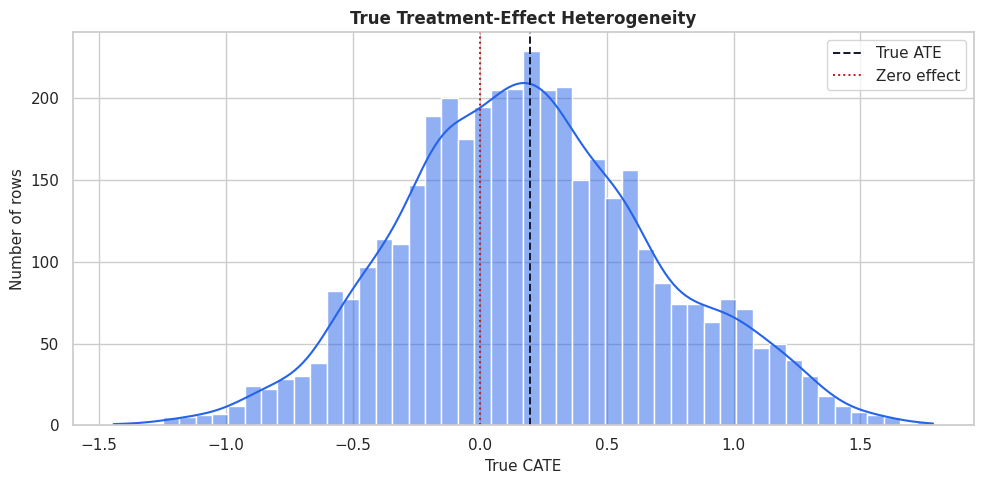

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(benchmark_df["true_cate"], bins=50, kde=True, color="#2563eb", ax=ax)
ax.axvline(benchmark_df["true_cate"].mean(), color="#111827", linestyle="--", linewidth=1.4, label="True ATE")
ax.axvline(0, color="#b91c1c", linestyle=":", linewidth=1.4, label="Zero effect")
ax.set_title("True Treatment-Effect Heterogeneity")
ax.set_xlabel("True CATE")
ax.set_ylabel("Number of rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution contains low-benefit and high-benefit regions. A good estimator should estimate the mean and identify the right tail well enough for targeting.



### Naive Treated-Control Difference

Before fitting causal estimators, we compute the raw treated-control difference. This is not a causal estimate because treatment assignment is confounded.

In [5]:
raw_group_summary = (
    benchmark_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        true_propensity_mean=("true_propensity", "mean"),
        high_need_rate=("high_need_segment", "mean"),
        low_friction_rate=("low_friction_segment", "mean"),
    )
    .reset_index()
)
raw_difference = raw_group_summary.loc[raw_group_summary["treatment"] == 1, "outcome_mean"].iloc[0] - raw_group_summary.loc[raw_group_summary["treatment"] == 0, "outcome_mean"].iloc[0]
raw_difference_vs_truth = pd.DataFrame(
    {
        "quantity": ["raw_treated_minus_control", "true_ate", "raw_minus_true_ate"],
        "value": [raw_difference, benchmark_df["true_cate"].mean(), raw_difference - benchmark_df["true_cate"].mean()],
    }
)

raw_group_summary.to_csv(TABLE_DIR / "13_raw_group_summary.csv", index=False)
raw_difference_vs_truth.to_csv(TABLE_DIR / "13_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_vs_truth)


,treatment,rows,outcome_mean,true_cate_mean,true_propensity_mean,high_need_rate,low_friction_rate
0,0,2241,1.105038,0.065412,0.388476,0.211959,0.352521
1,1,1759,2.096770,0.368029,0.524493,0.387152,0.475270


,quantity,value
0,raw_treated_minus_control,0.991732
1,true_ate,0.198488
2,raw_minus_true_ate,0.793244


The raw difference mixes true treatment effect with selection into treatment. The benchmark therefore needs estimators that adjust for observed confounding.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




### Covariate Balance

The code below computes standardized mean differences between treated and control rows. Large imbalance tells us where adjustment is needed.

In [6]:
# Save the artifacts produced by the Covariate Balance section.
feature_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "novelty_preference",
    "price_sensitivity",
    "account_tenure",
    "region_risk",
    "device_stability",
    "high_need_segment",
    "low_friction_segment",
]

balance_rows = []
for feature in feature_cols:
    treated_values = benchmark_df.loc[benchmark_df["treatment"] == 1, feature]
    control_values = benchmark_df.loc[benchmark_df["treatment"] == 0, feature]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    smd = (treated_values.mean() - control_values.mean()) / pooled_sd
    balance_rows.append(
        {
            "feature": feature,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_mean_difference": smd,
            "absolute_smd": abs(smd),
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("absolute_smd", ascending=False)
balance_table.to_csv(TABLE_DIR / "13_covariate_balance.csv", index=False)
display(balance_table)


,feature,treated_mean,control_mean,standardized_mean_difference,absolute_smd
0,baseline_need,0.293826,-0.243031,0.538938,0.538938
9,high_need_segment,0.387152,0.211959,0.389555,0.389555
2,friction_score,-0.193799,0.120983,-0.322196,0.322196
1,prior_engagement,0.195121,-0.105398,0.301412,0.301412
10,low_friction_segment,0.475270,0.352521,0.251115,0.251115
3,content_affinity,0.124215,-0.091619,0.218096,0.218096
4,novelty_preference,0.074636,-0.073350,0.150108,0.150108
7,region_risk,0.306424,0.277555,0.063510,0.063510
5,price_sensitivity,0.416023,0.422035,-0.030084,0.030084
6,account_tenure,48.985911,48.214979,0.028049,0.028049


The imbalance pattern confirms that treatment assignment is observational. This creates a meaningful benchmark for methods that model propensity, outcomes, or both.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


### Balance Plot

The plot makes the magnitude and direction of imbalance easier to scan than the table alone.

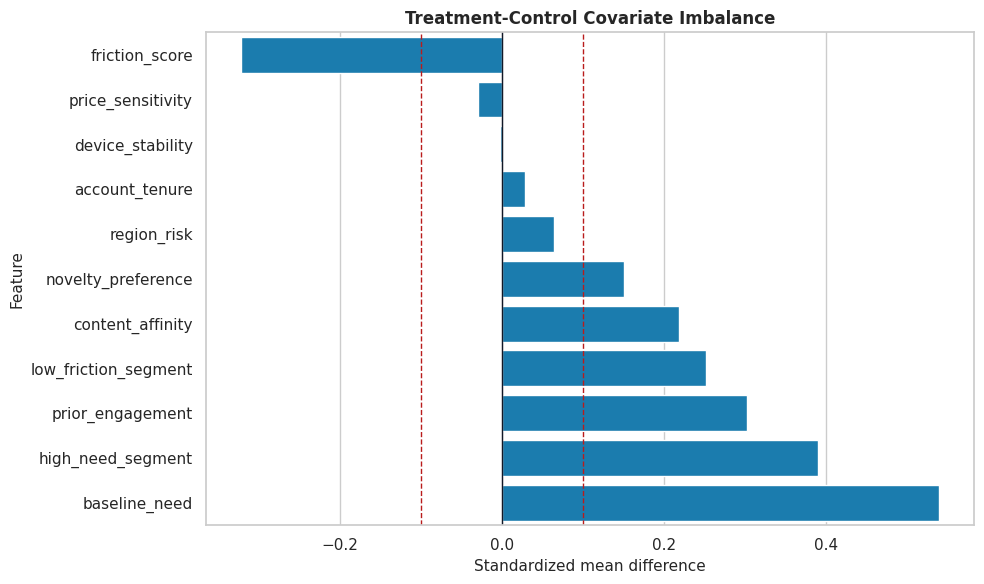

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_balance = balance_table.sort_values("standardized_mean_difference")
sns.barplot(data=plot_balance, x="standardized_mean_difference", y="feature", color="#0284c7", ax=ax)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#b91c1c", linestyle="--", linewidth=1)
ax.axvline(-0.10, color="#b91c1c", linestyle="--", linewidth=1)
ax.set_title("Treatment-Control Covariate Imbalance")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


Several features cross the practical imbalance threshold. The estimators will need to account for these differences to recover the causal effect.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->


#### Propensity Overlap

Overlap is essential for comparing treated and control outcomes within similar covariate regions. Here we can inspect the true synthetic propensity.

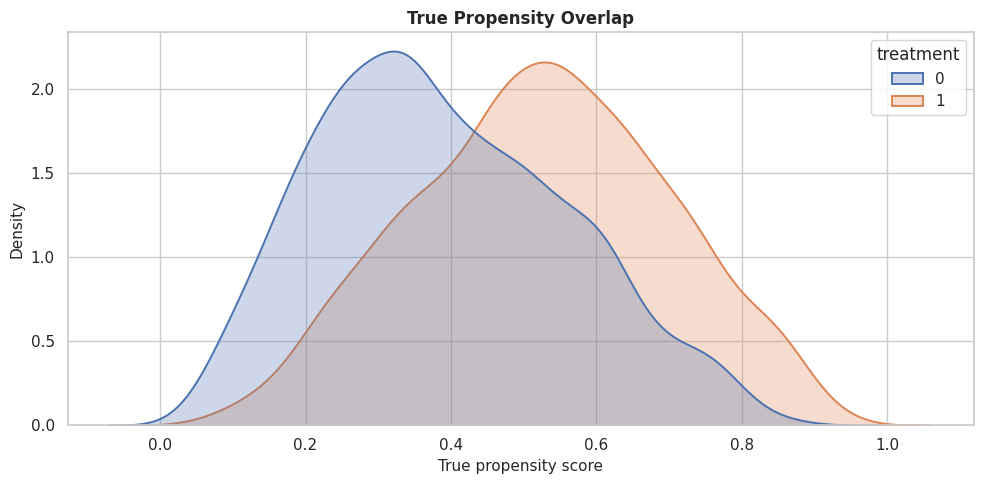

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=benchmark_df,
    x="true_propensity",
    hue="treatment",
    common_norm=False,
    fill=True,
    alpha=0.28,
    linewidth=1.4,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True propensity score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_true_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The treated and control distributions overlap, while treatment is clearly observational. That is the sweet spot for a useful teaching benchmark: confounding exists and overlap remains usable.



#### Train-Test Split

We split the data once and reuse the split for every estimator. Stratifying on treatment keeps treatment rates similar across training and test data.

In [9]:
train_df, test_df = train_test_split(
    benchmark_df,
    test_size=0.35,
    random_state=202613,
    stratify=benchmark_df["treatment"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "treatment_rate": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "outcome_mean": [train_df["outcome"].mean(), test_df["outcome"].mean()],
        "true_ate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
        "true_cate_std": [train_df["true_cate"].std(), test_df["true_cate"].std()],
    }
)

split_summary.to_csv(TABLE_DIR / "13_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,outcome_mean,true_ate,true_cate_std
0,train,2600,0.439615,1.536659,0.198415,0.505453
1,test,1400,0.440000,1.549496,0.198624,0.510053


The train and test splits are similar on treatment rate and true effect distribution. That makes held-out estimator comparisons more stable.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Model Matrices

The code below creates the model inputs shared by every estimator. The same feature matrix is used across the benchmark.

In [10]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df["outcome"].to_numpy()
y_test = test_df["outcome"].to_numpy()
t_train = train_df["treatment"].to_numpy()
t_test = test_df["treatment"].to_numpy()
true_tau_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    {
        "object": ["X_train", "X_test", "y_train", "t_train", "true_tau_test"],
        "shape_or_length": [X_train.shape, X_test.shape, len(y_train), len(t_train), len(true_tau_test)],
        "description": [
            "Shared covariate matrix for training.",
            "Shared covariate matrix for held-out evaluation.",
            "Training outcomes.",
            "Training treatment indicators.",
            "Teaching-only true CATE values for held-out evaluation.",
        ],
    }
)

matrix_summary.to_csv(TABLE_DIR / "13_model_matrix_summary.csv", index=False)
display(matrix_summary)


,object,shape_or_length,description
0,X_train,"(2600, 11)",Shared covariate matrix for training.
1,X_test,"(1400, 11)",Shared covariate matrix for held-out evaluation.
2,y_train,2600,Training outcomes.
3,t_train,2600,Training treatment indicators.
4,true_tau_test,1400,Teaching-only true CATE values for held-out evaluation.


The shared matrices are the foundation of a fair comparison. From here on, estimator differences are not due to different features or splits.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Nuisance Diagnostics

Before comparing CATE estimators, we check whether basic models can predict treatment and outcome. Strong nuisance signal is expected because treatment is confounded and the outcome is structured.

In [11]:
# Fit or evaluate the model objects used in the Nuisance Diagnostics section.
propensity_model = RandomForestClassifier(n_estimators=220, min_samples_leaf=25, random_state=202613, n_jobs=-1)
propensity_model.fit(X_train, t_train)
propensity_pred = np.clip(propensity_model.predict_proba(X_test)[:, 1], 1e-4, 1 - 1e-4)

outcome_model = RandomForestRegressor(n_estimators=220, min_samples_leaf=20, random_state=202614, n_jobs=-1)
outcome_model.fit(X_train.assign(treatment=t_train), y_train)
outcome_pred = outcome_model.predict(X_test.assign(treatment=t_test))

nuisance_diagnostics = pd.DataFrame(
    [
        {
            "model": "propensity_model",
            "metric_1": "roc_auc",
            "value_1": roc_auc_score(t_test, propensity_pred),
            "metric_2": "log_loss",
            "value_2": log_loss(t_test, propensity_pred),
        },
        {
            "model": "outcome_model",
            "metric_1": "rmse",
            "value_1": np.sqrt(mean_squared_error(y_test, outcome_pred)),
            "metric_2": "mae",
            "value_2": mean_absolute_error(y_test, outcome_pred),
        },
    ]
)

nuisance_diagnostics.to_csv(TABLE_DIR / "13_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)


,model,metric_1,value_1,metric_2,value_2
0,propensity_model,roc_auc,0.684963,log_loss,0.634215
1,outcome_model,rmse,0.873186,mae,0.691104


The propensity model can predict treatment assignment, so confounding is present. The outcome model also has signal, which should help estimators that rely on outcome nuisance models.



#### Define Estimators

The code below creates all estimators in the benchmark. The hyperparameters are intentionally moderate so the notebook runs quickly while still showing meaningful differences.

In [12]:
# Fit or evaluate the model objects used in the Define Estimators section.
estimators = {
    "LinearDML": LinearDML(
        model_y=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=202615, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=160, min_samples_leaf=25, random_state=202616, n_jobs=-1),
        discrete_treatment=True,
        featurizer=PolynomialFeatures(degree=2, include_bias=False),
        cv=3,
        random_state=202617,
    ),
    "CausalForestDML": CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=202618, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=160, min_samples_leaf=25, random_state=202619, n_jobs=-1),
        discrete_treatment=True,
        n_estimators=220,
        min_samples_leaf=18,
        max_samples=0.45,
        cv=3,
        random_state=202620,
        inference=True,
    ),
    "DRLearner": DRLearner(
        model_propensity=LogisticRegression(max_iter=1_000),
        model_regression=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202621, n_jobs=-1),
        model_final=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202622, n_jobs=-1),
        cv=3,
        random_state=202623,
    ),
    "SLearner": SLearner(
        overall_model=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202624, n_jobs=-1),
    ),
    "TLearner": TLearner(
        models=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202625, n_jobs=-1),
    ),
    "XLearner": XLearner(
        models=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202626, n_jobs=-1),
        cate_models=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202627, n_jobs=-1),
        propensity_model=LogisticRegression(max_iter=1_000),
    ),
}

estimator_setup = pd.DataFrame(
    [{"estimator": name, "python_class": estimator.__class__.__name__} for name, estimator in estimators.items()]
)
estimator_setup.to_csv(TABLE_DIR / "13_estimator_setup.csv", index=False)
display(estimator_setup)


,estimator,python_class
0,LinearDML,LinearDML
1,CausalForestDML,CausalForestDML
2,DRLearner,DRLearner
3,SLearner,SLearner
4,TLearner,TLearner
5,XLearner,XLearner


All estimators are now configured. Some use orthogonalization, some use doubly robust pseudo-outcomes, and some use meta-learner outcome-model contrasts.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Fit All Estimators

The code below fits every estimator and records runtime. The benchmark keeps fitting code centralized so every estimator is evaluated consistently.

In [13]:
fitted_estimators = {}
fit_records = []

for name, estimator in estimators.items():
    start_time = time.perf_counter()
    estimator.fit(y_train, t_train, X=X_train)
    elapsed = time.perf_counter() - start_time
    fitted_estimators[name] = estimator
    fit_records.append({"estimator": name, "fit_seconds": elapsed})

fit_runtime = pd.DataFrame(fit_records).sort_values("fit_seconds")
fit_runtime.to_csv(TABLE_DIR / "13_fit_runtime.csv", index=False)
display(fit_runtime)

,estimator,fit_seconds
3,SLearner,0.333538
4,TLearner,0.645458
5,XLearner,1.450110
2,DRLearner,2.039362
0,LinearDML,2.660424
1,CausalForestDML,3.221201


Runtime serves a different role than the main scientific metric. It matters in practice. A slower estimator may be worth it if it improves the decision metric that matters.

#### Predict Held-Out CATEs

After fitting, each estimator predicts treatment effects on the same held-out rows. We store all predictions in one table so downstream diagnostics are easy to compare.

In [14]:
prediction_records = []
effect_predictions = pd.DataFrame({"true_cate": true_tau_test})

for name, estimator in fitted_estimators.items():
    start_time = time.perf_counter()
    estimated_effect = np.ravel(estimator.effect(X_test, T0=0, T1=1))
    predict_seconds = time.perf_counter() - start_time
    effect_predictions[name] = estimated_effect
    prediction_records.append({"estimator": name, "predict_seconds": predict_seconds})

prediction_runtime = pd.DataFrame(prediction_records).sort_values("predict_seconds")
effect_predictions.to_csv(TABLE_DIR / "13_heldout_cate_predictions.csv", index=False)
prediction_runtime.to_csv(TABLE_DIR / "13_prediction_runtime.csv", index=False)
display(prediction_runtime)
display(effect_predictions.head())


,estimator,predict_seconds
0,LinearDML,0.003775
2,DRLearner,0.062459
1,CausalForestDML,0.075258
3,SLearner,0.111340
4,TLearner,0.158921
5,XLearner,0.196685


,true_cate,LinearDML,CausalForestDML,DRLearner,SLearner,TLearner,XLearner
0,0.376500,0.454522,0.404979,0.504012,0.569757,0.788655,0.506183
1,0.381832,0.066483,0.382831,0.257904,0.067475,0.324037,0.453422
2,0.088619,0.084981,0.281727,-0.087010,0.505844,0.403956,0.215171
3,-0.587649,0.133417,0.088856,0.075430,0.000000,0.330138,0.052100
4,0.436237,0.765672,0.288071,0.207394,0.150250,0.400706,0.139964


The prediction table is the central benchmark output. Every later comparison is computed from this shared held-out table.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Main Benchmark Metrics

The code below computes a shared metric set for every estimator: average-effect bias, CATE error, CATE correlation, positive-effect rate, and top-20-percent targeting value.

In [15]:
def summarize_estimator(name, estimate):
    """
    Compute common held-out benchmark metrics for one estimator.
    
    Parameters
    ----------
    name : str
        Short artifact or scenario name used for saving and labeling outputs.
    estimate : object
        Estimated effect or prediction vector being summarized or evaluated.
    
    Returns
    -------
    dict[str, float]
        Estimator-comparison row with ATE bias, CATE error, CATE correlation, and top-targeting diagnostics.
    """
    top_n = int(np.floor(0.20 * len(estimate)))
    top_idx = pd.Series(estimate).nlargest(top_n).index
    return {
        "estimator": name,
        "true_ate": true_tau_test.mean(),
        "estimated_ate": estimate.mean(),
        "ate_bias": estimate.mean() - true_tau_test.mean(),
        "absolute_ate_bias": abs(estimate.mean() - true_tau_test.mean()),
        "cate_rmse": np.sqrt(mean_squared_error(true_tau_test, estimate)),
        "cate_mae": mean_absolute_error(true_tau_test, estimate),
        "cate_correlation": np.corrcoef(true_tau_test, estimate)[0, 1],
        "share_estimated_positive": np.mean(estimate > 0),
        "top_20_true_cate_mean": true_tau_test[top_idx].mean(),
        "top_20_estimated_cate_mean": estimate[top_idx].mean(),
        "top_20_true_negative_share": np.mean(true_tau_test[top_idx] < 0),
    }

benchmark_metrics = pd.DataFrame(
    [summarize_estimator(name, effect_predictions[name].to_numpy()) for name in estimators.keys()]
).merge(fit_runtime, on="estimator", how="left").merge(prediction_runtime, on="estimator", how="left")

benchmark_metrics = benchmark_metrics.sort_values("cate_rmse").reset_index(drop=True)
benchmark_metrics.to_csv(TABLE_DIR / "13_benchmark_metrics.csv", index=False)
display(benchmark_metrics)


,estimator,true_ate,estimated_ate,ate_bias,absolute_ate_bias,cate_rmse,cate_mae,cate_correlation,share_estimated_positive,top_20_true_cate_mean,top_20_estimated_cate_mean,top_20_true_negative_share,fit_seconds,predict_seconds
0,XLearner,0.198624,0.273604,0.074980,0.074980,0.274628,0.211060,0.855292,0.694286,0.850097,0.907916,0.000000,1.450110,0.196685
1,SLearner,0.198624,0.308376,0.109752,0.109752,0.301581,0.229460,0.836177,0.793571,0.892449,1.008308,0.000000,0.333538,0.111340
2,DRLearner,0.198624,0.227230,0.028606,0.028606,0.314199,0.244116,0.813802,0.662857,0.856903,0.984641,0.000000,2.039362,0.062459
3,CausalForestDML,0.198624,0.301709,0.103085,0.103085,0.318455,0.245165,0.913821,0.893571,0.895554,0.672566,0.000000,3.221201,0.075258
4,LinearDML,0.198624,0.290684,0.092060,0.092060,0.393217,0.288085,0.761342,0.665714,0.798281,1.154401,0.021429,2.660424,0.003775
5,TLearner,0.198624,0.408943,0.210319,0.210319,0.435578,0.331652,0.719571,0.773571,0.846643,1.153384,0.007143,0.645458,0.158921


The table is the main leaderboard, but it should not be read as a single universal ranking. CATE RMSE, ATE bias, and targeting value can point to different choices.

#### Metric Ranking Table

A compact rank table helps compare estimators across several objectives. Lower rank is better for each metric.

In [16]:
rank_table = benchmark_metrics[["estimator"]].copy()
rank_table["rmse_rank"] = benchmark_metrics["cate_rmse"].rank(method="min", ascending=True).astype(int)
rank_table["ate_bias_rank"] = benchmark_metrics["absolute_ate_bias"].rank(method="min", ascending=True).astype(int)
rank_table["correlation_rank"] = benchmark_metrics["cate_correlation"].rank(method="min", ascending=False).astype(int)
rank_table["targeting_rank"] = benchmark_metrics["top_20_true_cate_mean"].rank(method="min", ascending=False).astype(int)
rank_table["runtime_rank"] = benchmark_metrics["fit_seconds"].rank(method="min", ascending=True).astype(int)
rank_table["average_rank"] = rank_table[["rmse_rank", "ate_bias_rank", "correlation_rank", "targeting_rank", "runtime_rank"]].mean(axis=1)
rank_table = rank_table.sort_values("average_rank").reset_index(drop=True)

rank_table.to_csv(TABLE_DIR / "13_metric_rank_table.csv", index=False)
display(rank_table)

,estimator,rmse_rank,ate_bias_rank,correlation_rank,targeting_rank,runtime_rank,average_rank
0,XLearner,1,2,2,4,3,2.4
1,SLearner,2,5,3,2,1,2.6
2,DRLearner,3,1,4,3,4,3.0
3,CausalForestDML,4,4,1,1,6,3.2
4,LinearDML,5,3,5,6,5,4.8
5,TLearner,6,6,6,5,2,5.0


The average rank is a simple summary, not a decision rule. A real project should weight metrics based on the use case: estimation accuracy, targeting, or runtime.



#### CATE RMSE and ATE Bias Plot

This plot shows two different ways an estimator can be good or bad: pointwise CATE recovery and average-effect bias.

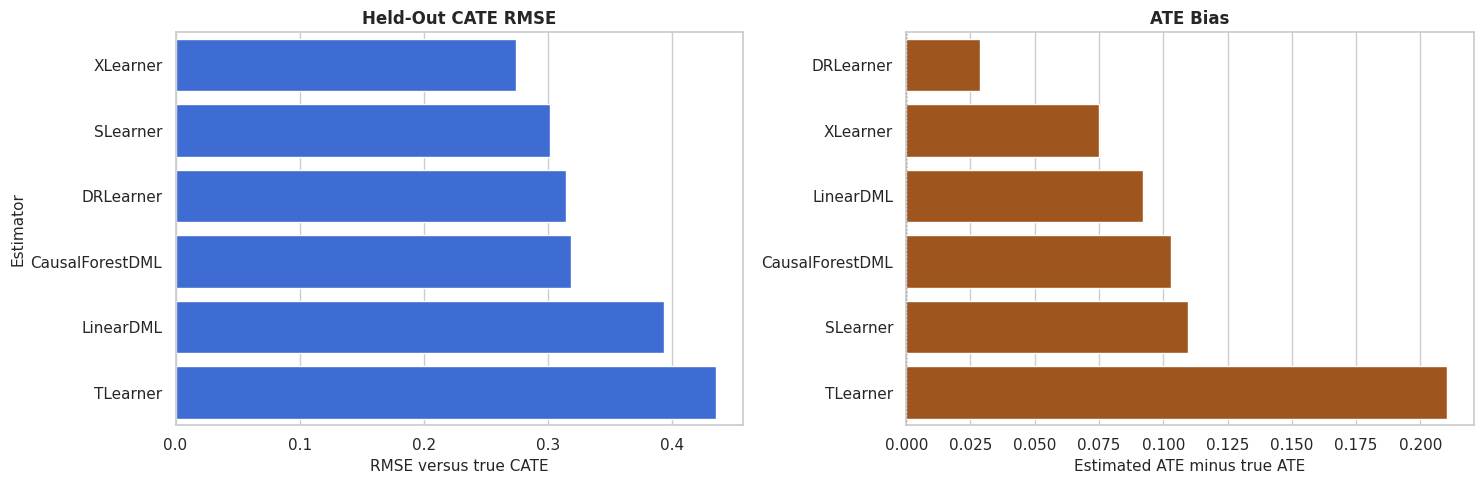

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_metrics = benchmark_metrics.sort_values("cate_rmse")

sns.barplot(data=plot_metrics, x="cate_rmse", y="estimator", color="#2563eb", ax=axes[0])
axes[0].set_title("Held-Out CATE RMSE")
axes[0].set_xlabel("RMSE versus true CATE")
axes[0].set_ylabel("Estimator")

bias_plot = benchmark_metrics.sort_values("ate_bias")
sns.barplot(data=bias_plot, x="ate_bias", y="estimator", color="#b45309", ax=axes[1])
axes[1].axvline(0, color="#111827", linestyle=":", linewidth=1)
axes[1].set_title("ATE Bias")
axes[1].set_xlabel("Estimated ATE minus true ATE")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_rmse_and_ate_bias.png", dpi=160, bbox_inches="tight")
plt.show()


The side-by-side view is useful because average-effect accuracy and row-level recovery are different goals. An estimator can be close on the ATE while still ranking rows poorly.



#### CATE Recovery Scatterplots

Scatterplots compare true and estimated CATE values directly. The diagonal line marks perfect recovery.

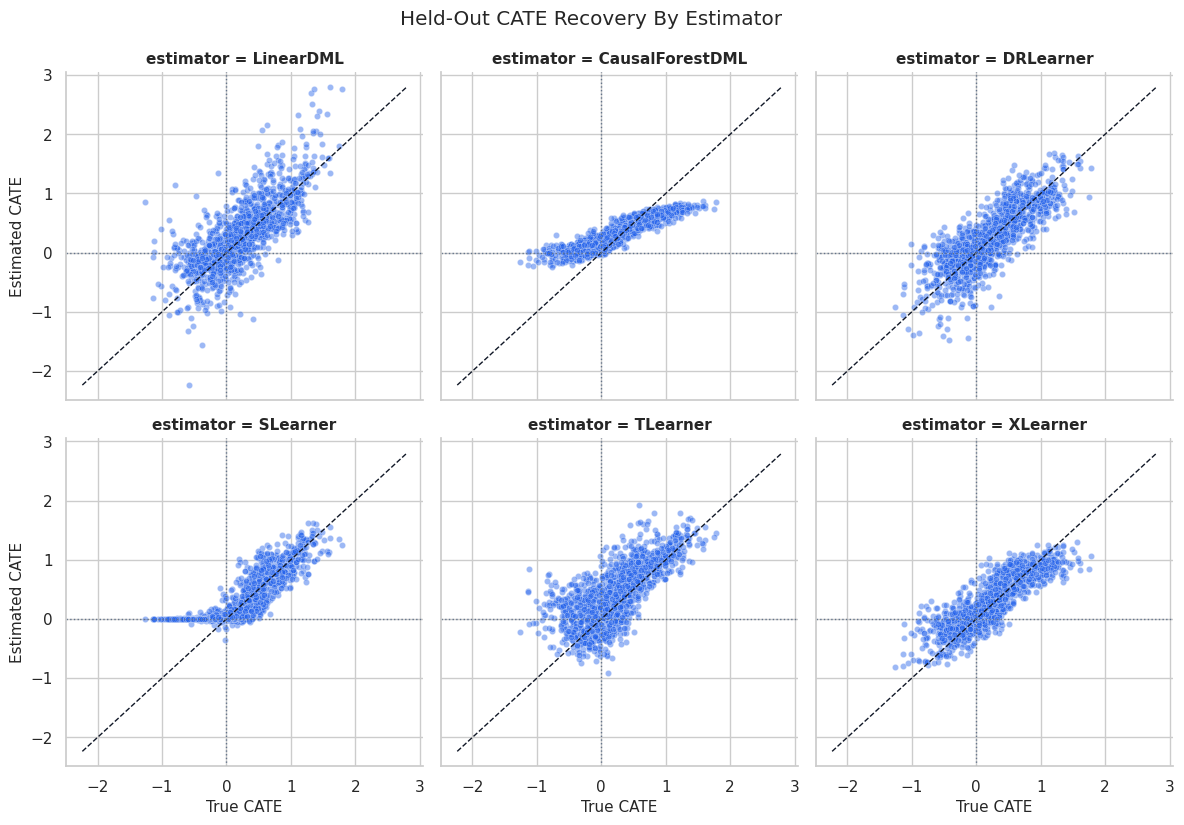

In [18]:
scatter_data = effect_predictions.melt(
    id_vars="true_cate",
    value_vars=list(estimators.keys()),
    var_name="estimator",
    value_name="estimated_cate",
)

g = sns.FacetGrid(scatter_data, col="estimator", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="true_cate", y="estimated_cate", alpha=0.45, s=20, color="#2563eb")

for ax in g.axes.flat:
    lims = [
        min(scatter_data["true_cate"].min(), scatter_data["estimated_cate"].min()),
        max(scatter_data["true_cate"].max(), scatter_data["estimated_cate"].max()),
    ]
    ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1)
    ax.axhline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.axvline(0, color="#64748b", linestyle=":", linewidth=1)

g.set_axis_labels("True CATE", "Estimated CATE")
g.fig.suptitle("Held-Out CATE Recovery By Estimator", y=1.03)
g.fig.savefig(FIGURE_DIR / "13_cate_recovery_scatterplots.png", dpi=160, bbox_inches="tight")
plt.show()


The scatterplots show shape differences that a table can hide. Some estimators may compress the range, while others may capture ranking but have level bias.

#### Ranking and Targeting Comparison

Many applied CATE workflows use estimates for ranking. The code below compares the true CATE among rows selected by each estimator's top 20 percent.

In [19]:
# Save the artifacts produced by the Ranking And Targeting Comparison section.
top_n = int(np.floor(0.20 * len(test_df)))
targeting_rows = []
for name in estimators.keys():
    estimates = effect_predictions[name]
    selected_idx = estimates.nlargest(top_n).index
    selected = test_df.loc[selected_idx]
    targeting_rows.append(
        {
            "estimator": name,
            "selected_rows": len(selected_idx),
            "selected_share": len(selected_idx) / len(test_df),
            "mean_estimated_cate_selected": estimates.loc[selected_idx].mean(),
            "mean_true_cate_selected": test_df.loc[selected_idx, "true_cate"].mean(),
            "share_true_cate_negative_selected": (test_df.loc[selected_idx, "true_cate"] < 0).mean(),
            "high_need_rate_selected": selected["high_need_segment"].mean(),
            "low_friction_rate_selected": selected["low_friction_segment"].mean(),
        }
    )

oracle_idx = test_df["true_cate"].nlargest(top_n).index
targeting_rows.append(
    {
        "estimator": "Oracle true CATE",
        "selected_rows": len(oracle_idx),
        "selected_share": len(oracle_idx) / len(test_df),
        "mean_estimated_cate_selected": np.nan,
        "mean_true_cate_selected": test_df.loc[oracle_idx, "true_cate"].mean(),
        "share_true_cate_negative_selected": (test_df.loc[oracle_idx, "true_cate"] < 0).mean(),
        "high_need_rate_selected": test_df.loc[oracle_idx, "high_need_segment"].mean(),
        "low_friction_rate_selected": test_df.loc[oracle_idx, "low_friction_segment"].mean(),
    }
)

targeting_summary = pd.DataFrame(targeting_rows).sort_values("mean_true_cate_selected", ascending=False)
targeting_summary.to_csv(TABLE_DIR / "13_targeting_summary.csv", index=False)
display(targeting_summary)


,estimator,selected_rows,selected_share,mean_estimated_cate_selected,mean_true_cate_selected,share_true_cate_negative_selected,high_need_rate_selected,low_friction_rate_selected
6,Oracle true CATE,280,0.2,NaN,0.954328,0.000000,0.875000,0.471429
1,CausalForestDML,280,0.2,0.672566,0.895554,0.000000,0.807143,0.475000
3,SLearner,280,0.2,1.008308,0.892449,0.000000,0.835714,0.421429
2,DRLearner,280,0.2,0.984641,0.856903,0.000000,0.753571,0.467857
5,XLearner,280,0.2,0.907916,0.850097,0.000000,0.746429,0.421429
4,TLearner,280,0.2,1.153384,0.846643,0.007143,0.764286,0.446429
0,LinearDML,280,0.2,1.154401,0.798281,0.021429,0.685714,0.432143


The targeting table evaluates a decision-oriented question: which estimator finds high-benefit rows? The oracle row shows the upper benchmark available only in synthetic data.

#### Targeting Plot

This plot compares the true effect among selected rows. It is a high-signal output for prioritization use cases.


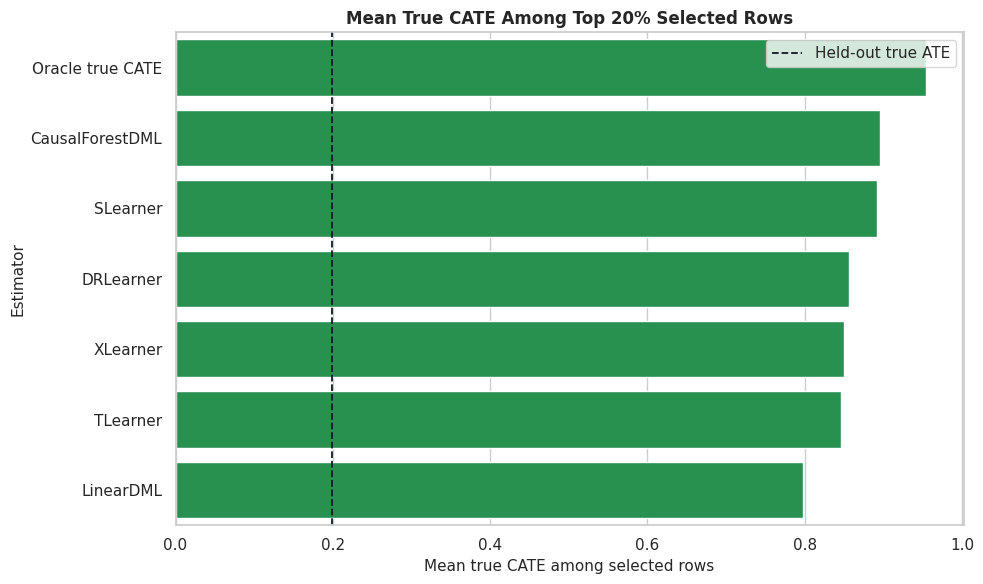

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=targeting_summary, x="mean_true_cate_selected", y="estimator", color="#16a34a", ax=ax)
ax.axvline(test_df["true_cate"].mean(), color="#111827", linestyle="--", linewidth=1.3, label="Held-out true ATE")
ax.set_title("Mean True CATE Among Top 20% Selected Rows")
ax.set_xlabel("Mean true CATE among selected rows")
ax.set_ylabel("Estimator")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()

Estimators with better top-group true effects are better for this specific targeting rule. That may or may not match the ranking by CATE RMSE.

#### Decile Calibration

Decile calibration checks whether rows with higher estimated CATE also have higher true CATE on average. This is a useful ranking diagnostic.

In [21]:
decile_rows = []
for name in estimators.keys():
    temp = pd.DataFrame({"estimated_cate": effect_predictions[name], "true_cate": true_tau_test})
    temp["decile"] = pd.qcut(temp["estimated_cate"], q=10, labels=False, duplicates="drop") + 1
    decile_summary = (
        temp.groupby("decile", observed=True)
        .agg(
            rows=("true_cate", "size"),
            mean_estimated_cate=("estimated_cate", "mean"),
            mean_true_cate=("true_cate", "mean"),
        )
        .reset_index()
    )
    decile_summary["estimator"] = name
    decile_rows.append(decile_summary)

decile_calibration = pd.concat(decile_rows, ignore_index=True)
decile_calibration.to_csv(TABLE_DIR / "13_decile_calibration.csv", index=False)
display(decile_calibration.head(15))


,decile,rows,mean_estimated_cate,mean_true_cate,estimator
0,1,140,-0.602850,-0.291655,LinearDML
1,2,140,-0.237903,-0.232706,LinearDML
2,3,140,-0.105576,-0.167671,LinearDML
3,4,140,0.019309,-0.069742,LinearDML
4,5,140,0.163088,0.038262,LinearDML
5,6,140,0.304745,0.252068,LinearDML
6,7,140,0.451947,0.379142,LinearDML
7,8,140,0.605282,0.481980,LinearDML
8,9,140,0.863357,0.647574,LinearDML
9,10,140,1.445445,0.948989,LinearDML


A well-ranked estimator should show increasing true CATE as the estimated-CATE decile rises. The next plot makes that pattern easier to compare across estimators.

#### Decile Calibration Plot

This plot shows the mean true CATE within estimated-CATE deciles for each estimator. Steeper upward curves indicate better ranking separation.

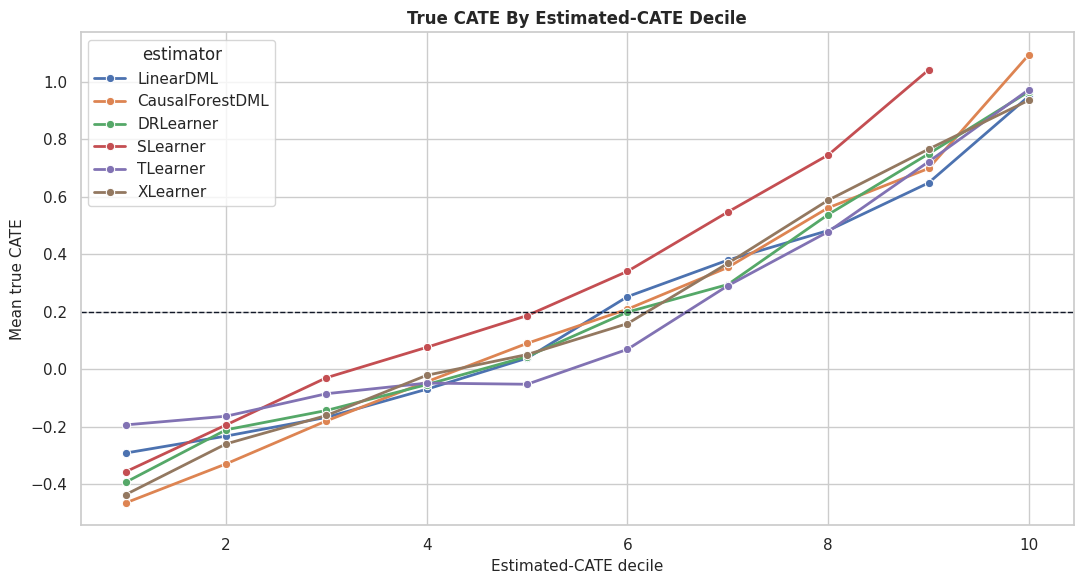

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=decile_calibration, x="decile", y="mean_true_cate", hue="estimator", marker="o", linewidth=2, ax=ax)
ax.axhline(test_df["true_cate"].mean(), color="#111827", linestyle="--", linewidth=1, label="Held-out true ATE")
ax.set_title("True CATE By Estimated-CATE Decile")
ax.set_xlabel("Estimated-CATE decile")
ax.set_ylabel("Mean true CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

The calibration curves show which estimators create useful separation between low-benefit and high-benefit rows. This can matter more than exact row-level CATE values for targeting workflows.

#### Segment-Level Benchmark

Segment summaries check whether estimators behave differently across important groups. Here we compare regular and high-need rows, crossed with friction level.

In [23]:
# Save the artifacts produced by the Segment-Level Benchmark section.
segment_eval = test_df[["baseline_need", "friction_score", "high_need_segment", "low_friction_segment", "true_cate"]].copy()
segment_eval["need_segment"] = np.where(segment_eval["high_need_segment"] == 1, "high need", "regular need")
segment_eval["friction_segment"] = np.where(segment_eval["low_friction_segment"] == 1, "low friction", "regular/high friction")
for name in estimators.keys():
    segment_eval[name] = effect_predictions[name]

segment_rows = []
for name in estimators.keys():
    grouped = (
        segment_eval.groupby(["need_segment", "friction_segment"], observed=True)
        .apply(
            lambda g: pd.Series(
                {
                    "rows": len(g),
                    "true_cate_mean": g["true_cate"].mean(),
                    "estimated_cate_mean": g[name].mean(),
                    "segment_bias": g[name].mean() - g["true_cate"].mean(),
                    "segment_rmse": np.sqrt(mean_squared_error(g["true_cate"], g[name])),
                }
            ),
            include_groups=False,
        )
        .reset_index()
    )
    grouped["estimator"] = name
    segment_rows.append(grouped)

segment_benchmark = pd.concat(segment_rows, ignore_index=True)
segment_benchmark.to_csv(TABLE_DIR / "13_segment_benchmark.csv", index=False)
display(segment_benchmark.head(20))


,need_segment,friction_segment,rows,true_cate_mean,estimated_cate_mean,segment_bias,segment_rmse,estimator
0,high need,low friction,151.0,0.845285,0.824273,-0.021013,0.404828,LinearDML
1,high need,regular/high friction,238.0,0.699039,0.798205,0.099166,0.384243,LinearDML
2,regular need,low friction,413.0,0.088037,0.160352,0.072316,0.402211,LinearDML
3,regular need,regular/high friction,598.0,-0.087450,0.043971,0.131420,0.387448,LinearDML
4,high need,low friction,151.0,0.845285,0.614162,-0.231123,0.326750,CausalForestDML
5,high need,regular/high friction,238.0,0.699039,0.548773,-0.150267,0.316387,CausalForestDML
6,regular need,low friction,413.0,0.088037,0.249144,0.161107,0.269908,CausalForestDML
7,regular need,regular/high friction,598.0,-0.087450,0.160786,0.248235,0.346860,CausalForestDML
8,high need,low friction,151.0,0.845285,0.787213,-0.058073,0.268847,DRLearner
9,high need,regular/high friction,238.0,0.699039,0.608320,-0.090719,0.327050,DRLearner


The segment table reveals whether an estimator is consistently accurate or only good in aggregate. Segment failures can be hidden by overall metrics.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Segment Bias Heatmap

This heatmap visualizes segment bias by estimator. Values near zero indicate segment-level average effects are close to truth.

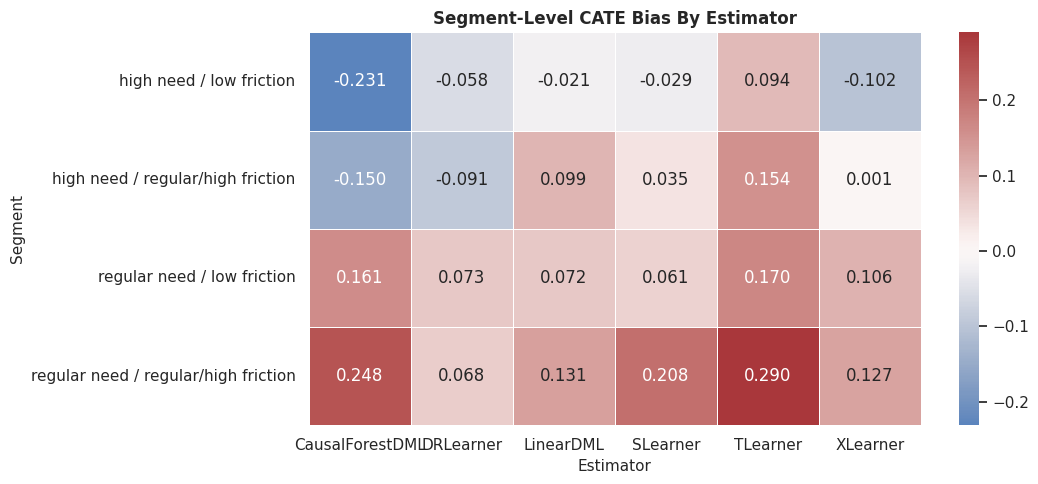

In [24]:
segment_benchmark["segment"] = segment_benchmark["need_segment"] + " / " + segment_benchmark["friction_segment"]
segment_bias_heatmap = segment_benchmark.pivot(index="segment", columns="estimator", values="segment_bias")

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(segment_bias_heatmap, annot=True, fmt=".3f", cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Segment-Level CATE Bias By Estimator")
ax.set_xlabel("Estimator")
ax.set_ylabel("Segment")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_segment_bias_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap shows where estimators overstate or understate effects. This is often the start of a deeper model diagnostics conversation.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Runtime versus Accuracy

This plot compares fit runtime with CATE RMSE. It helps students see the practical tradeoff between computation and accuracy.

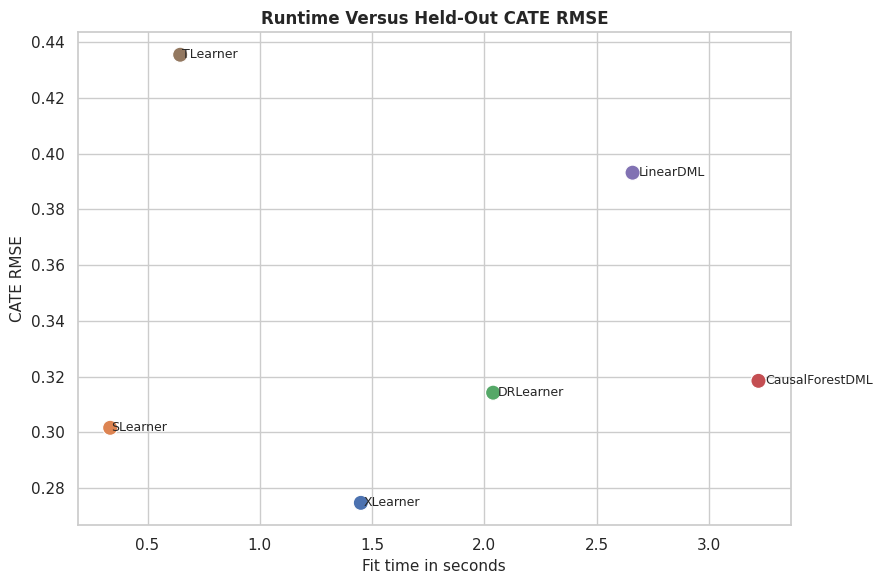

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=benchmark_metrics, x="fit_seconds", y="cate_rmse", hue="estimator", s=120, ax=ax)
for _, row in benchmark_metrics.iterrows():
    ax.text(row["fit_seconds"] * 1.01, row["cate_rmse"], row["estimator"], fontsize=9, va="center")
ax.set_title("Runtime Versus Held-Out CATE RMSE")
ax.set_xlabel("Fit time in seconds")
ax.set_ylabel("CATE RMSE")
ax.legend_.remove()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_runtime_vs_accuracy.png", dpi=160, bbox_inches="tight")
plt.show()

Fast models are not automatically worse, and slow models are not automatically better. Runtime is one practical constraint among several.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->


#### Robustness Across Bootstrap Resamples

A benchmark can be sensitive to one particular test sample. This lightweight bootstrap resamples held-out rows and recomputes the CATE RMSE for each estimator without refitting models.

In [26]:
bootstrap_rows = []
n_bootstrap = 300
for name in estimators.keys():
    estimates = effect_predictions[name].to_numpy()
    bootstrap_rmse = []
    for _ in range(n_bootstrap):
        sample_idx = rng.choice(np.arange(len(true_tau_test)), size=len(true_tau_test), replace=True)
        bootstrap_rmse.append(np.sqrt(mean_squared_error(true_tau_test[sample_idx], estimates[sample_idx])))
    bootstrap_rows.append(
        {
            "estimator": name,
            "rmse_mean": np.mean(bootstrap_rmse),
            "rmse_ci_lower": np.quantile(bootstrap_rmse, 0.025),
            "rmse_ci_upper": np.quantile(bootstrap_rmse, 0.975),
        }
    )

bootstrap_rmse_summary = pd.DataFrame(bootstrap_rows).sort_values("rmse_mean")
bootstrap_rmse_summary.to_csv(TABLE_DIR / "13_bootstrap_rmse_summary.csv", index=False)
display(bootstrap_rmse_summary)


,estimator,rmse_mean,rmse_ci_lower,rmse_ci_upper
5,XLearner,0.274994,0.262322,0.286412
3,SLearner,0.301513,0.287719,0.314949
2,DRLearner,0.313532,0.300537,0.325110
1,CausalForestDML,0.318517,0.305690,0.331115
0,LinearDML,0.392984,0.373317,0.414053
4,TLearner,0.436275,0.418239,0.456594


The bootstrap intervals summarize test-sample uncertainty in the RMSE comparison. They exclude refitting uncertainty, yet they help avoid overreading tiny leaderboard gaps.

#### Bootstrap RMSE Plot

The plot shows RMSE means with bootstrap intervals. Overlapping intervals are a cue that estimator differences may not be decisive.

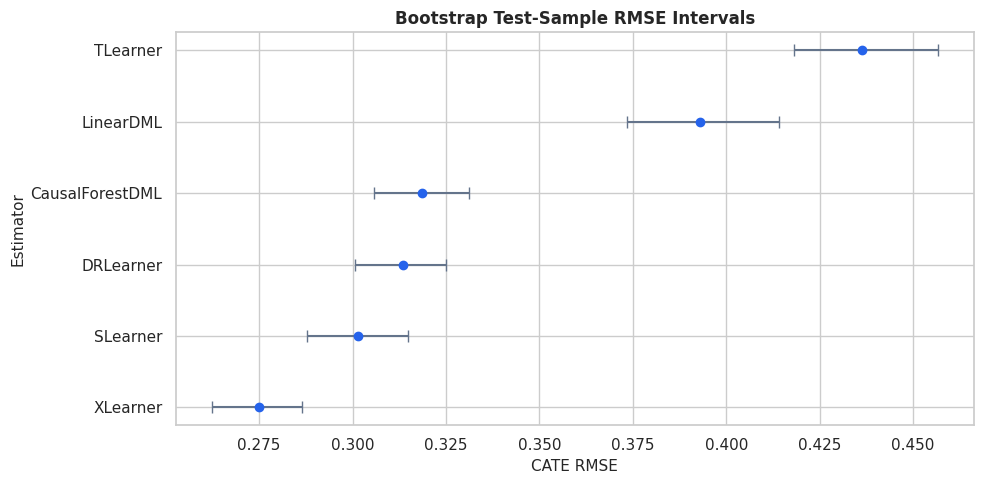

In [27]:
plot_boot = bootstrap_rmse_summary.sort_values("rmse_mean")
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=plot_boot["rmse_mean"],
    y=plot_boot["estimator"],
    xerr=[plot_boot["rmse_mean"] - plot_boot["rmse_ci_lower"], plot_boot["rmse_ci_upper"] - plot_boot["rmse_mean"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.set_title("Bootstrap Test-Sample RMSE Intervals")
ax.set_xlabel("CATE RMSE")
ax.set_ylabel("Estimator")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_bootstrap_rmse_intervals.png", dpi=160, bbox_inches="tight")
plt.show()


The intervals make the benchmark more honest. A small apparent win may not matter if it sits inside the uncertainty band.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Estimator Selection Guidance

This table translates the benchmark into practical guidance. The right estimator depends on whether the goal is interpretability, nonlinear recovery, targeting, runtime, or robustness.

| use_case | estimator_to_try_first | what_to_check |
| --- | --- | --- |
| Need a transparent baseline | LinearDML | ATE bias, coefficient signs, and whether nonlinear estimators improve CATE recovery. |
| Expect nonlinear heterogeneity | CausalForestDML or forest-based DRLearner | CATE RMSE, decile calibration, and segment behavior. |
| Prioritization or targeting | The estimator with best top-group true effect in simulation or strongest validation proxy in real data. | Top-decile value, calibration curves, and stability across resamples. |
| Fast benchmark baseline | SLearner or TLearner | Whether simple outcome-model contrasts are competitive before using heavier methods. |
| Imbalanced treatment assignment | XLearner or DRLearner | Overlap, propensity quality, and selected-group composition. |
| Final reporting | Do not rely on one estimator only | Agreement across families, segment diagnostics, uncertainty, and sensitivity to assumptions. |


The guidance keeps the benchmark from becoming a mechanical leaderboard. Estimator choice should reflect the causal question and the decision workflow.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Final Benchmark Checklist

This checklist summarizes the steps needed for a fair estimator comparison in a real analysis.

| step | why_it_matters |
| --- | --- |
| Define the estimand | Estimator comparison is meaningless if methods are answering different causal questions. |
| Use one split and one feature set | Preprocessing differences can masquerade as estimator differences. |
| Check overlap and balance first | Estimator sophistication cannot fix severe support problems. |
| Evaluate average and heterogeneous metrics | ATE accuracy and CATE ranking are different objectives. |
| Inspect calibration and segments | Overall metrics can hide subgroup failures. |
| Track runtime and complexity | The best estimator must also be maintainable and rerunnable. |
| Avoid declaring universal winners | The best choice depends on data support, assumptions, and the downstream decision. |


The checklist is the portable lesson from this lesson. Use benchmarks to learn estimator behavior, not to crown a universal champion.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Summary

This lesson compared six EconML estimators on the same nonlinear binary-treatment ground truth.

The main lessons are:

- Estimator comparisons should use the same split, same features, and same metrics.
- ATE bias, CATE RMSE, CATE correlation, targeting value, and runtime answer different questions.
- Orthogonal estimators and meta-learners can excel under different conditions.
- Decile calibration is useful when treatment-effect estimates will be used for ranking.
- Segment diagnostics can reveal failures that aggregate metrics hide.
- Bootstrap test-sample intervals help prevent overreading tiny leaderboard gaps.
- The right estimator is the one that best supports the causal question and downstream decision.

The next tutorial combines many of these ingredients into an end-to-end case study.